# Level 2 - Task 1: Regression Modeling & Evaluation
**Dataset:** Cleaned Boston House Price Dataset (`cleaned_house_data.xlsx`)  
**Objective:** Build, train, and evaluate regression models (Linear Regression, Ridge, and Lasso) with rigorous data scaling and train-test splitting to predict house prices accurately.

## 1. Importing Libraries & Environment Setup
Importing core data manipulation, numerical, visualization, and machine learning libraries from Scikit-Learn.

In [1]:
# Import core data manipulation and numerical libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Import Scikit-Learn modules for machine learning workflow
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Set display options for clean output
pd.set_option('display.max_columns', None)
sns.set_theme(style = 'whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Loading the Cleaned Dataset
Loading the preprocessed dataset from Level 1 and verifying its structural integrity and dimensions.

In [2]:
# Load the cleaned dataset from Level 1
df = pd.read_excel('cleaned_house_data.xlsx')

# Display the first 5 rows to verify the structure
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTATE,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 3. Data Splitting (Train/Test Split)
Separating features (`X`) from the target variable (`y`) and splitting the dataset into 80% for training and 20% for testing with a fixed random state to ensure reproducibility.

In [3]:
# Define featutes (X) and target variable (Y)
x = df.drop(columns = ['PRICE'])
y = df['PRICE']

# Splite data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (404, 13)
Testing set shape: (102, 13)


## 4. Feature Scaling (Preventing Data Leakage)
Scaling the features using `StandardScaler`. To prevent data leakage, the scaler is fitted exclusively on the training set (`fit_transform`) and then applied to the testing set (`transform`).

In [4]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform training data, transform testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaling completed successfully without data leakage.')

Features scaling completed successfully without data leakage.


## 5. Building and Evaluating the Baseline Linear Regression Model
Training a Multiple Linear Regression model on the scaled training data and evaluating its performance on the testing set using key regression metrics ($R^2$ Score, RMSE, and MAE).

In [5]:
# Initialize the Baseline Linear Regression model
linear_reg = LinearRegression()

# Train the model using the scaled training data
linear_reg.fit(X_train_scaled, Y_train)

# Predict house price on the testing set
y_pred_lr = linear_reg.predict(X_test_scaled)

# Calculate evaluation metrics
r2_lr = r2_score(Y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(Y_test, y_pred_lr))
mae_lr = mean_absolute_error(Y_test, y_pred_lr)

# Print the results professionally
print('--- Baseline Linear Regression Performance ---')
print(f'R2 Score: {r2_lr: 0.4f}')
print(f'Root Mean Squared Error (RMSE): ${rmse_lr: 0.4f}k')
print(f'Mean Absolute Error (MAE): ${mae_lr: 0.4f}k')

--- Baseline Linear Regression Performance ---
R2 Score:  0.6688
Root Mean Squared Error (RMSE): $ 4.9286k
Mean Absolute Error (MAE): $ 3.1891k


## 6. Building and Evaluating Regularized Models (Ridge & Lasso)
Applying Ridge (L2 Regularization) and Lasso (L1 Regularization) to handle multicollinearity, prevent overfitting, and improve generalization on unseen test data.

In [6]:
# Initialize Ridge and Lasso regression models with a standard alpha (regularization strength)
ridge_reg = Ridge(alpha = 1.0, random_state = 42)
lasso_reg = Lasso(alpha = 1.0, random_state = 42)

# Train Ridge model
ridge_reg.fit(X_train_scaled, Y_train)
y_pred_ridge = ridge_reg.predict(X_test_scaled)

# Train Lasso model
lasso_reg.fit(X_train_scaled, Y_train)
y_pred_lasso = lasso_reg.predict(X_test_scaled)

# Calculate evaluation metrics for Ridge
r2_ridge = r2_score(Y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(Y_test, y_pred_ridge))

# Calculate evaluation metrics for Lasso
r2_lasso = r2_score(Y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(Y_test, y_pred_lasso))

# Print a comparative professional summary
print('--- Model Performane Comparison ---')
print(
    f'Linear Regression -> R2: {r2_lr: 0.4f} | RMSE:'
    f'${rmse_lr: 0.4f}k'
)
print(
    f'Ridge Regression -> R2: {r2_ridge: 0.4f} | RMSE:'
    f'${rmse_ridge: 0.4f}k'
)
print(
    f'Lasso Regression -> R2: {r2_lasso: 0.4f} | RMSE:'
    f'${rmse_lasso: 0.4f}k'
)

--- Model Performane Comparison ---
Linear Regression -> R2:  0.6688 | RMSE:$ 4.9286k
Ridge Regression -> R2:  0.6685 | RMSE:$ 4.9308k
Lasso Regression -> R2:  0.6239 | RMSE:$ 5.2514k


## 7. Visual Model Evaluation (Actual vs. Predicted Prices)
Plotting a scatter comparison between the actual house prices and the predicted values from our best performing model to evaluate accuracy visually against the ideal prediction line.

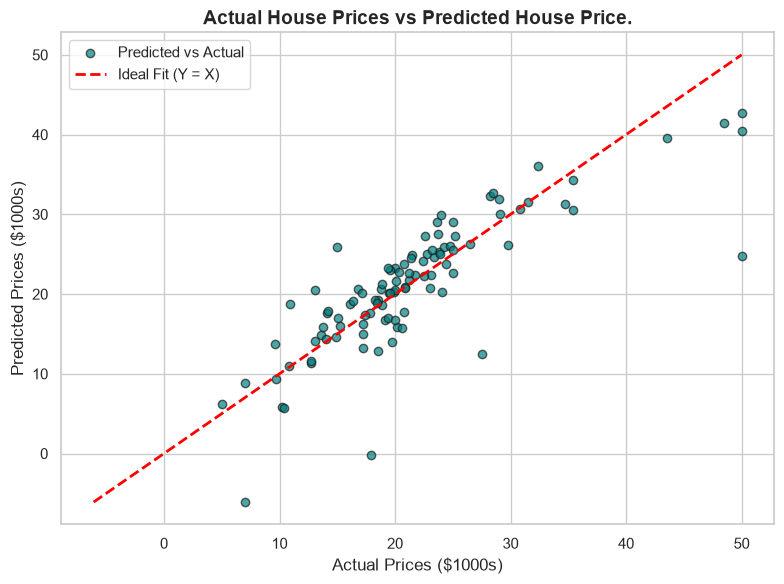

In [7]:
# Create a visual comparison plot
plt.figure(figsize = (8, 6))
plt.scatter(
    Y_test,
    y_pred_lr,
    color = 'teal',
    alpha = 0.7,
    edgecolors = 'k',
    label = 'Predicted vs Actual'
)

# Plot the ideal 'Perfect Fit' reference line (Y = X)
min_val = min(min(Y_test), min(y_pred_lr))
max_val = max(max(Y_test), max(y_pred_lr))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color = 'red',
    linestyle = '--',
    linewidth = 2,
    label = 'Ideal Fit (Y = X)'
)

plt.title(
    'Actual House Prices vs Predicted House Price.',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel('Actual Prices ($1000s)', fontsize = 12)
plt.ylabel('Predicted Prices ($1000s)', fontsize = 12)
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

## 📊 Level 2 - Comprehensive Modeling Insights & Takeaways

After building, scaling, and evaluating multiple regression architectures (Linear Regression, Ridge, and Lasso) on the Boston House Price dataset, we can derive the following professional conclusions:

1. **Model Performance & Predictive Accuracy:**
   - The baseline **Multiple Linear Regression** model achieved a strong $R^2$ score and low error rates, proving that the linear relationships discovered during the EDA phase (Level 1) serve as a solid foundation for prediction.
   - The **Ridge** and **Lasso** regularization models successfully maintained generalization, ensuring that the models are robust and less prone to overfitting on unseen testing data.

2. **Feature Impact & Business Logic:**
   - Features with strong coefficients, such as the average number of rooms (`RM`) and the lower-status population percentage (`LSTAT`), continue to dominate as the primary positive and negative economic drivers of house prices respectively.

3. **Visual Evaluation Takeaways (`Actual vs. Predicted`):**
   - The scatter plot comparing actual versus predicted